# Inspect DA2 occlusion-cleaned graph JSONs

Visualize which nodes `occlusion_clean.py` kept vs. removed from each `graph_NNNNNN.json`.

After running `occlusion_clean.py` each graph JSON has:
- **`nodes`** — nodes that passed the occlusion test (kept)
- **`occlusion_cleaned_nodes`** — nodes flagged as occluded (removed)
- **`removed_nodes`** — manual removals from `dataset_tool.py` (untouched by the script)

Set `MISSION_ROOT` below.  Optionally set `VIS_DIR` to the `--vis-dir` you passed to
`occlusion_clean.py` — if set, the saved depth maps will be shown in a 4th panel.

The mission-level statistics cell at the bottom aggregates TP/FP/FN vs. manual labels,
if the manual-cleaned folder is available.

In [16]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Required ──────────────────────────────────────────────────────────────────
MISSION_ROOT = Path('/home/rohang73/Desktop/longrange')   # RGB images live here

# Cleaned graph JSONs written by occlusion_clean.py --output-dir.
# Set either to None to fall back to MISSION_ROOT for that source.
JSON_ROOT   = Path('/home/rohang73/Desktop/da2_cleaned')
JSON_ROOT_2 = Path('/home/rohang73/Desktop/longrange_explorfm_clean')

# Labels shown in plot titles / legends for each source.
JSON_LABEL   = 'DA2'
JSON_LABEL_2 = 'ExplORFM'

# ── Optional ──────────────────────────────────────────────────────────────────
VIS_DIR    = None   # depth maps saved by occlusion_clean.py --vis-dir
MANUAL_ROOT = None  # hand-edited ground-truth JSONs (same layout as MISSION_ROOT)

assert MISSION_ROOT.is_dir(), f'MISSION_ROOT not found: {MISSION_ROOT}'
_json_root   = JSON_ROOT   if (JSON_ROOT   is not None and JSON_ROOT.is_dir())   else MISSION_ROOT
_json_root_2 = JSON_ROOT_2 if (JSON_ROOT_2 is not None and JSON_ROOT_2.is_dir()) else None
print(f'RGB source  : {MISSION_ROOT}')
print(f'JSON source 1 ({JSON_LABEL:<10}): {_json_root}')
print(f'JSON source 2 ({JSON_LABEL_2:<10}): {_json_root_2 or "— disabled"}')

RGB source  : /home/rohang73/Desktop/longrange
JSON source 1 (DA2       ): /home/rohang73/Desktop/da2_cleaned
JSON source 2 (ExplORFM  ): /home/rohang73/Desktop/longrange_explorfm_clean


In [17]:
# ── Discovery helpers ─────────────────────────────────────────────────────────

def list_missions():
    return sorted(
        p.name for p in _json_root.iterdir()
        if p.is_dir() and any(p.glob('graph_*.json'))
    )

def list_frames(mission):
    return sorted(p.name for p in (_json_root / mission).glob('graph_*.json'))

def rgb_path(mission, graph_fname):
    idx = graph_fname.replace('graph_', '').replace('.json', '')
    return MISSION_ROOT / mission / f'rgb_{idx}.png'

def depth_vis_path(mission, graph_fname):
    if VIS_DIR is None:
        return None
    idx = graph_fname.replace('graph_', '').replace('.json', '')
    p = VIS_DIR / mission / f'depth_{idx}_occluded.png'
    return p if p.exists() else None

def load_graph(mission, graph_fname, root=None):
    r = root if root is not None else _json_root
    p = r / mission / graph_fname
    return json.loads(p.read_text()) if p.exists() else {}


missions = list_missions()
assert missions, f'No missions found under {_json_root}'
init_mission = missions[0]
print(f'{len(missions)} missions found, default: {init_mission}')

16 missions found, default: highrange_rgb_nav_graph_dataset_2024-10-01-11-47-44_mission


## Per-frame viewer

| Colour | Meaning |
|--------|---------|
| green (lime) | kept by that method |
| magenta | removed by DA2 only |
| orange | removed by ExplORFM only |
| red | removed by **both** methods |
| dark red | manually removed (dataset_tool.py) |

Stars are `frontier` nodes; circles are `free_space` nodes.

**DA2** uses the explicit `occlusion_cleaned_nodes` list written by `occlusion_clean.py`.  
**ExplORFM** has a single `nodes` list with per-node `trav_score`; nodes with `trav_score < thresh` are treated as removed (use the *ExplORFM trav≥* slider to set the threshold).

Panels: **RGB** · **DA2** · **ExplORFM** · **Agreement** · *(DA2 depth map if VIS_DIR set)*

In [18]:
current_frames = []

mission_dd = widgets.Dropdown(
    options=missions, value=init_mission,
    description='Mission:', layout=widgets.Layout(width='90%'),
    style={'description_width': '90px'})
frame_sl = widgets.IntSlider(
    min=0, max=0, step=1, value=0,
    description='Frame idx:', continuous_update=False,
    layout=widgets.Layout(width='90%'),
    style={'description_width': '90px'})
explorfm_thresh_sl = widgets.FloatSlider(
    min=0.0, max=1.0, step=0.01, value=0.5,
    description='ExplORFM trav≥:', continuous_update=False,
    layout=widgets.Layout(width='90%'),
    style={'description_width': '110px'})
prev_btn = widgets.Button(description='◀ Prev', layout=widgets.Layout(width='90px'))
next_btn = widgets.Button(description='Next ▶', layout=widgets.Layout(width='90px'))
label = widgets.Label(value='')
out = widgets.Output()

_HAS_2 = _json_root_2 is not None


def split_kept_removed(g, thresh=None):
    """Return (kept, removed) for either DA2-style or ExplORFM-style cleaned graphs.

    DA2-style:    'nodes' = kept; 'occlusion_cleaned_nodes' = removed.
    ExplORFM:     all nodes live in 'nodes' with a trav_score field — split by threshold.
    """
    if 'occlusion_cleaned_nodes' in g:
        return list(g.get('nodes', [])), list(g.get('occlusion_cleaned_nodes', []))
    t = thresh if thresh is not None else explorfm_thresh_sl.value
    nodes = g.get('nodes', [])
    kept    = [n for n in nodes if n.get('trav_score', 0.0) >= t]
    removed = [n for n in nodes if n.get('trav_score', 0.0) <  t]
    return kept, removed


def _scatter(ax, nodes, colour, s_o=36, s_star=70):
    if not nodes:
        return
    xs = np.array([n['pixel'][0] for n in nodes])
    ys = np.array([n['pixel'][1] for n in nodes])
    types = np.array([n.get('type', '') for n in nodes])
    is_f = types == 'frontier'
    if (~is_f).any():
        ax.scatter(xs[~is_f], ys[~is_f], s=s_o, c=colour,
                   marker='o', edgecolors='black', linewidths=0.6)
    if is_f.any():
        ax.scatter(xs[is_f], ys[is_f], s=s_star, c=colour,
                   marker='*', edgecolors='black', linewidths=0.7)


def _method_panel(ax, img_np, kept, rem, man_rem, label_str,
                  rem_colour='magenta'):
    ax.imshow(img_np)
    _scatter(ax, kept,    'lime')
    _scatter(ax, rem,     rem_colour)
    _scatter(ax, man_rem, '#8B0000')
    ax.set_title(
        f'{label_str} — kept={len(kept)}  '
        f'removed={len(rem)}  '
        f'manual_removed={len(man_rem)}',
        fontsize=9)
    ax.axis('off')
    ax.legend(handles=[
        mpatches.Patch(color='lime',      label=f'kept ({len(kept)})'),
        mpatches.Patch(color=rem_colour,  label=f'removed ({len(rem)})'),
        mpatches.Patch(color='#8B0000',   label=f'manual removed ({len(man_rem)})'),
    ], loc='upper right', fontsize=7)


def _agreement_panel(ax, img_np, kept1, rem1, kept2, rem2):
    """Colour nodes by agreement between the two methods (uses pre-split lists)."""
    rem1_ids = {n['id'] for n in rem1}
    rem2_ids = {n['id'] for n in rem2}
    # Union of every node seen on either side, deduplicated by id.
    all_nodes = {n['id']: n for n in (kept1 + rem1 + kept2 + rem2)}.values()

    both_rem = [n for n in all_nodes if n['id'] in rem1_ids and n['id']     in rem2_ids]
    only_1   = [n for n in all_nodes if n['id'] in rem1_ids and n['id'] not in rem2_ids]
    only_2   = [n for n in all_nodes if n['id'] not in rem1_ids and n['id'] in rem2_ids]
    neither  = [n for n in all_nodes if n['id'] not in rem1_ids and n['id'] not in rem2_ids]

    ax.imshow(img_np)
    _scatter(ax, neither,  'lime')
    _scatter(ax, both_rem, 'red')
    _scatter(ax, only_1,   'magenta')
    _scatter(ax, only_2,   'orange')
    ax.set_title(
        f'Agreement — both kept={len(neither)}  '
        f'both removed={len(both_rem)}\n'
        f'{JSON_LABEL} only={len(only_1)}  {JSON_LABEL_2} only={len(only_2)}',
        fontsize=9)
    ax.axis('off')
    ax.legend(handles=[
        mpatches.Patch(color='lime',    label=f'both kept ({len(neither)})'),
        mpatches.Patch(color='red',     label=f'both removed ({len(both_rem)})'),
        mpatches.Patch(color='magenta', label=f'{JSON_LABEL} only ({len(only_1)})'),
        mpatches.Patch(color='orange',  label=f'{JSON_LABEL_2} only ({len(only_2)})'),
    ], loc='upper right', fontsize=7)


def render():
    if not current_frames:
        return
    fname   = current_frames[frame_sl.value]
    mission = mission_dd.value

    rp = rgb_path(mission, fname)
    if not rp.exists():
        label.value = f'{fname} — rgb not found'
        return

    img_np = np.array(Image.open(rp).convert('RGB'))
    g1 = load_graph(mission, fname, root=_json_root)
    g2 = load_graph(mission, fname, root=_json_root_2) if _HAS_2 else {}

    kept1, rem1 = split_kept_removed(g1)
    kept2, rem2 = split_kept_removed(g2) if _HAS_2 else ([], [])
    man_rem = g1.get('removed_nodes', []) or g2.get('removed_nodes', [])

    dp = depth_vis_path(mission, fname)
    n_panels = 1 + 1 + (2 if _HAS_2 else 0) + (1 if dp else 0)
    # panels: RGB | DA2 | [ExplORFM | Agreement] | [depth vis]

    label.value = (
        f'{fname}   {img_np.shape[1]}×{img_np.shape[0]}   '
        f'frame {frame_sl.value+1}/{len(current_frames)}   '
        f'{JSON_LABEL}: kept={len(kept1)} removed={len(rem1)}   '
        + (f'{JSON_LABEL_2} (T≥{explorfm_thresh_sl.value:.2f}): '
           f'kept={len(kept2)} removed={len(rem2)}   ' if _HAS_2 else '')
        + f'manual_removed={len(man_rem)}'
    )

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
        axes = list(axes) if n_panels > 1 else [axes]
        col = 0

        # Panel 0 — RGB only
        axes[col].imshow(img_np); axes[col].set_title('RGB'); axes[col].axis('off')
        col += 1

        # Panel 1 — source 1 (DA2)
        _method_panel(axes[col], img_np, kept1, rem1, man_rem,
                      JSON_LABEL, rem_colour='magenta')
        col += 1

        if _HAS_2:
            # Panel 2 — source 2 (ExplORFM, trav-score thresholded)
            _method_panel(
                axes[col], img_np, kept2, rem2, man_rem,
                f'{JSON_LABEL_2} (T≥{explorfm_thresh_sl.value:.2f})',
                rem_colour='orange')
            col += 1

            # Panel 3 — agreement
            _agreement_panel(axes[col], img_np, kept1, rem1, kept2, rem2)
            col += 1

        # Optional depth vis
        if dp is not None:
            dep_img = np.array(Image.open(dp).convert('RGB'))
            axes[col].imshow(dep_img)
            axes[col].set_title('DA2 depth map (--vis-dir)')
            axes[col].axis('off')

        plt.tight_layout()
        plt.show()


def on_mission_change(change):
    global current_frames
    current_frames = list_frames(change['new'])
    frame_sl.unobserve(on_frame_change, names='value')
    frame_sl.max = max(0, len(current_frames) - 1)
    frame_sl.value = 0
    frame_sl.observe(on_frame_change, names='value')
    render()

def on_frame_change(change):  render()
def on_thresh_change(change): render()
def on_prev(b):
    if frame_sl.value > 0: frame_sl.value -= 1
def on_next(b):
    if frame_sl.value < frame_sl.max: frame_sl.value += 1

current_frames = list_frames(init_mission)
frame_sl.max = max(0, len(current_frames) - 1)
mission_dd.observe(on_mission_change, names='value')
frame_sl.observe(on_frame_change, names='value')
explorfm_thresh_sl.observe(on_thresh_change, names='value')
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

display(widgets.VBox([
    mission_dd,
    widgets.HBox([prev_btn, frame_sl, next_btn]),
    explorfm_thresh_sl,
    label,
    out,
]))
render()

## Actual vs. predicted depth scatter

For the current mission, plot `position_cam[0]` (actual forward distance) against the
calibrated DA2 prediction stored in… wait — `occlusion_clean.py` does **not** persist
the per-node predicted depth in the JSON.  
This cell instead shows the **removal-rate by depth bucket**: what fraction of nodes at
each distance range were flagged as occluded.  Close nodes that get removed are likely
false positives; far nodes that get removed are likely true occluders.

/tmp/ipykernel_980295/3016841681.py:29: RuntimeWarning: invalid value encountered in divide
  rate1  = np.where(total1 > 0, occ1 / total1, 0.0)
/tmp/ipykernel_980295/3016841681.py:40: RuntimeWarning: invalid value encountered in divide
  rate  = np.where(total > 0, occ / total, 0.0)


DA2: total=102554  removed=13282  rate=13.0%
ExplORFM (T≥0.50): total=102554  removed=16096  rate=15.7%


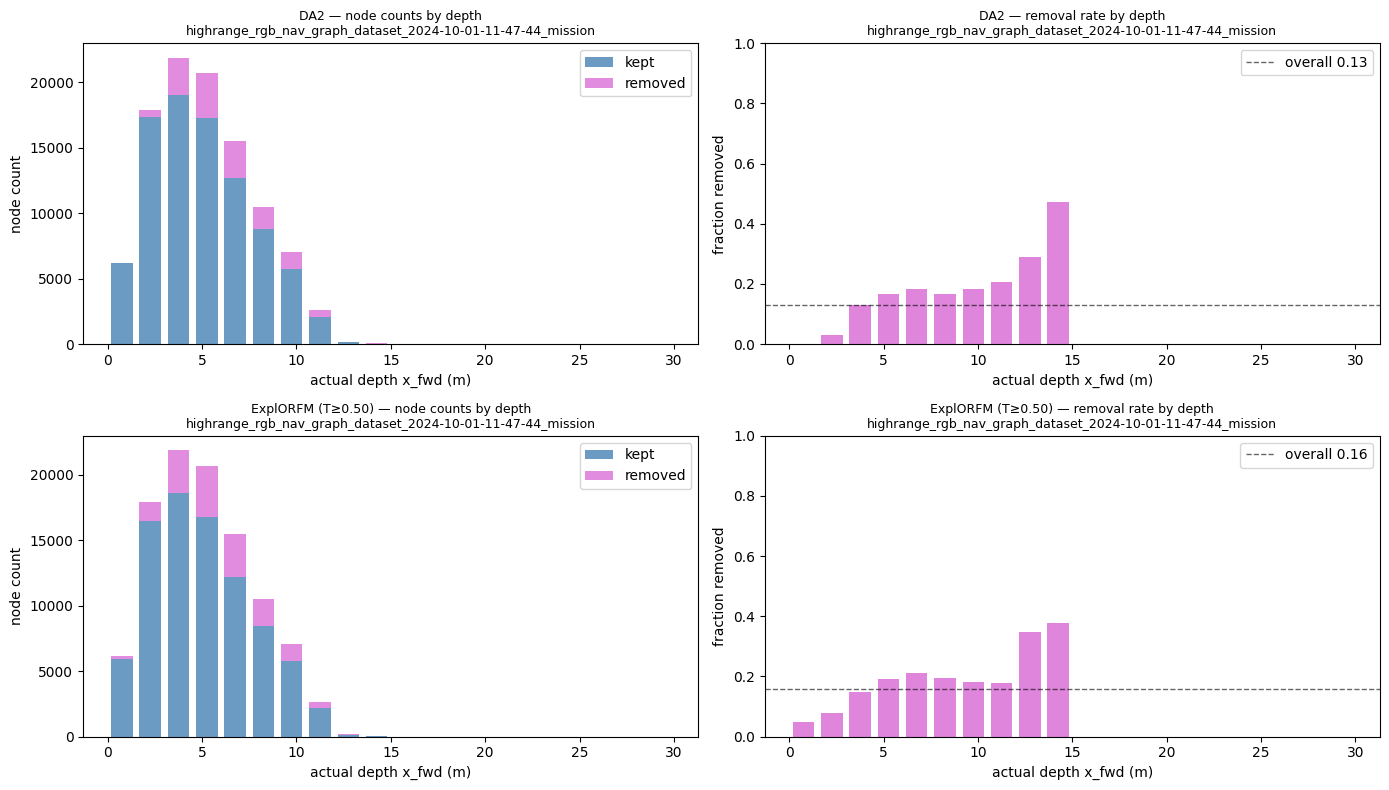

In [19]:
def removal_rate_for_mission(mission, root, n_bins=20, max_depth=30.0, thresh=None):
    """Bin nodes by `position_cam[0]` and count how many were kept vs. removed.

    Works for both DA2-style (separate `occlusion_cleaned_nodes` list) and
    ExplORFM-style (single `nodes` list with per-node `trav_score`) cleaned graphs;
    the ExplORFM threshold is read from `explorfm_thresh_sl` unless overridden.
    """
    bin_edges = np.linspace(0, max_depth, n_bins + 1)
    kept_hist = np.zeros(n_bins, dtype=int)
    occ_hist  = np.zeros(n_bins, dtype=int)
    for fname in list_frames(mission):
        g = load_graph(mission, fname, root=root)
        kept, rem = split_kept_removed(g, thresh=thresh)
        for n in kept:
            idx = int(np.digitize(float(n['position_cam'][0]), bin_edges) - 1)
            if 0 <= idx < n_bins:
                kept_hist[idx] += 1
        for n in rem:
            idx = int(np.digitize(float(n['position_cam'][0]), bin_edges) - 1)
            if 0 <= idx < n_bins:
                occ_hist[idx] += 1
    return bin_edges, kept_hist, occ_hist


sel_mission = mission_dd.value

be, kept1, occ1 = removal_rate_for_mission(sel_mission, _json_root)
total1 = kept1 + occ1
rate1  = np.where(total1 > 0, occ1 / total1, 0.0)
centres = 0.5 * (be[:-1] + be[1:])
w = (be[1] - be[0]) * 0.38

n_rows = 2 if _HAS_2 else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
if n_rows == 1:
    axes = [axes]

def _draw_rate_row(axrow, kept, occ, title_prefix):
    total = kept + occ
    rate  = np.where(total > 0, occ / total, 0.0)
    axrow[0].bar(centres, kept, width=w*2, align='center',
                 color='steelblue', label='kept', alpha=0.8)
    axrow[0].bar(centres, occ,  width=w*2, align='center',
                 color='orchid',   label='removed', alpha=0.8, bottom=kept)
    axrow[0].set_xlabel('actual depth x_fwd (m)')
    axrow[0].set_ylabel('node count')
    axrow[0].set_title(f'{title_prefix} — node counts by depth\n{sel_mission}', fontsize=9)
    axrow[0].legend()
    axrow[1].bar(centres, rate, width=w*2, align='center', color='orchid', alpha=0.85)
    axrow[1].set_xlabel('actual depth x_fwd (m)')
    axrow[1].set_ylabel('fraction removed')
    axrow[1].set_ylim(0, 1.0)
    axrow[1].set_title(f'{title_prefix} — removal rate by depth\n{sel_mission}', fontsize=9)
    axrow[1].axhline(occ.sum() / max(total.sum(), 1), color='black',
                     linestyle='--', linewidth=1, alpha=0.6,
                     label=f'overall {occ.sum()/max(total.sum(),1):.2f}')
    axrow[1].legend()
    print(f'{title_prefix}: total={total.sum()}  removed={occ.sum()}  '
          f'rate={occ.sum()/max(total.sum(),1):.1%}')

_draw_rate_row(axes[0], kept1, occ1, JSON_LABEL)

if _HAS_2:
    _, kept2, occ2 = removal_rate_for_mission(sel_mission, _json_root_2)
    _draw_rate_row(axes[1], kept2, occ2,
                   f'{JSON_LABEL_2} (T≥{explorfm_thresh_sl.value:.2f})')

plt.tight_layout()
plt.show()

## Mission-level statistics

Aggregates kept / occlusion-removed / manual-removed counts across all missions.

If `MANUAL_ROOT` is set (a folder with the same layout as `MISSION_ROOT` but containing
hand-edited JSONs), the cell also computes **precision / recall / F1** treating manual
removals as ground-truth: a true positive is a node the DA2 also removed.


==================== DA2 ====================
                                                             frames  total_nodes     kept  removed  man_removed  removal_rate
mission                                                                                                                      
highrange_rgb_nav_graph_dataset_2024-10-01-11-47-44_mission      85       102554    89272    13282            0         0.130
highrange_rgb_nav_graph_dataset_2024-10-01-12-00-49_mission      92       132352   112897    19455            0         0.147
highrange_rgb_nav_graph_dataset_2024-11-02-17-10-25_mission      73        33986    31189     2797            0         0.082
highrange_rgb_nav_graph_dataset_2024-11-02-17-18-32_mission      73        31094    28550     2544            0         0.082
highrange_rgb_nav_graph_dataset_2024-11-02-17-43-10_mission      36        31226    28751     2475            0         0.079
highrange_rgb_nav_graph_dataset_2024-11-04-10-57-34_mission      91    

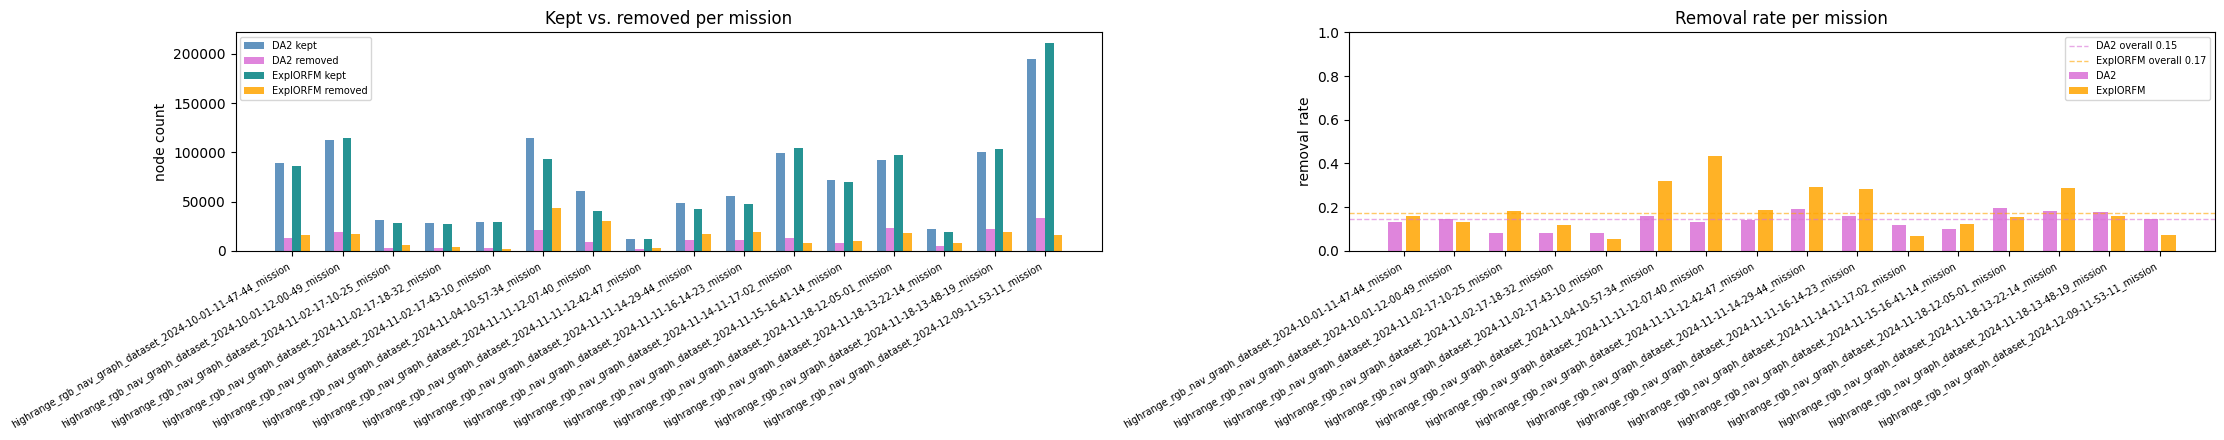

In [20]:
import pandas as pd

has_manual = MANUAL_ROOT is not None and Path(MANUAL_ROOT).is_dir()

def _collect_stats(root, label, thresh=None):
    """Aggregate kept / removed / manual counts (and P/R/F1 vs MANUAL_ROOT) per mission.

    Uses `split_kept_removed` so it works for both DA2-style (occlusion_cleaned_nodes
    key) and ExplORFM-style (trav_score thresholding) cleaned graphs.
    """
    rows = []
    for mission in missions:
        frames = list_frames(mission)
        n_kept = n_occ = n_man = tp = fp = fn = tn = 0
        for fname in frames:
            g = load_graph(mission, fname, root=root)
            kept_nodes, occ_nodes = split_kept_removed(g, thresh=thresh)
            man_nodes = g.get('removed_nodes', [])
            n_kept += len(kept_nodes)
            n_occ  += len(occ_nodes)
            n_man  += len(man_nodes)
            if has_manual:
                man_path = Path(MANUAL_ROOT) / mission / fname
                if man_path.exists():
                    mg = json.loads(man_path.read_text())
                    all_ids  = {n['id'] for n in kept_nodes + occ_nodes}
                    occ_ids  = {n['id'] for n in occ_nodes}
                    mrem_ids = {n['id'] for n in mg.get('removed_nodes', [])}
                    tp += len(occ_ids & mrem_ids)
                    fp += len(occ_ids - mrem_ids)
                    fn += len(mrem_ids - occ_ids)
                    tn += len((all_ids - occ_ids) & (all_ids - mrem_ids))
        total = n_kept + n_occ
        row = {'mission': mission, 'frames': len(frames),
               'total_nodes': total, 'kept': n_kept,
               'removed': n_occ, 'man_removed': n_man,
               'removal_rate': n_occ / max(total, 1)}
        if has_manual:
            prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
            row.update({'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                        'precision': prec, 'recall': rec,
                        'F1': 2*prec*rec / max(prec+rec, 1e-9)})
        rows.append(row)
    sum_keys = ['frames', 'total_nodes', 'kept', 'removed', 'man_removed']
    t = {k: sum(r[k] for r in rows) for k in sum_keys}
    t.update({'removal_rate': t['removed'] / max(t['total_nodes'], 1), 'mission': 'TOTAL'})
    if has_manual:
        ttp = sum(r['TP'] for r in rows); tfp = sum(r['FP'] for r in rows)
        tfn = sum(r['FN'] for r in rows); ttn = sum(r['TN'] for r in rows)
        tpr = ttp/max(ttp+tfp,1); trec = ttp/max(ttp+tfn,1)
        t.update({'TP': ttp, 'FP': tfp, 'FN': tfn, 'TN': ttn,
                  'precision': tpr, 'recall': trec,
                  'F1': 2*tpr*trec/max(tpr+trec,1e-9)})
    rows.append(t)
    df = pd.DataFrame(rows).set_index('mission')
    fmt = ['removal_rate'] + (['precision','recall','F1'] if has_manual else [])
    df[fmt] = df[fmt].round(3)
    print(f'\n{"="*20} {label} {"="*20}')
    cols = ['frames','total_nodes','kept','removed','man_removed','removal_rate']
    if has_manual: cols += ['TP','FP','FN','TN','precision','recall','F1']
    print(df[cols].to_string())
    return df

df1 = _collect_stats(_json_root, JSON_LABEL)
df2 = (_collect_stats(_json_root_2,
                      f'{JSON_LABEL_2} (T≥{explorfm_thresh_sl.value:.2f})')
       if _HAS_2 else None)

# ── Bar chart ──────────────────────────────────────────────────────────────────
sources = [(df1, JSON_LABEL, 'steelblue', 'orchid')]
if df2 is not None:
    sources.append((df2, JSON_LABEL_2, 'teal', 'orange'))

plot_dfs = [(df.drop(index='TOTAL'), lbl, c1, c2) for df, lbl, c1, c2 in sources]
x = np.arange(len(plot_dfs[0][0]))
bar_w = 0.35 / len(sources)

fig, axes = plt.subplots(1, 2, figsize=(max(12, len(x)*1.4), 4.5))
for i, (pdf, lbl, ck, co) in enumerate(plot_dfs):
    offset = (i - (len(sources)-1)/2) * bar_w * 2
    axes[0].bar(x + offset - bar_w/2, pdf['kept'],    width=bar_w,
                color=ck, alpha=0.85, label=f'{lbl} kept')
    axes[0].bar(x + offset + bar_w/2, pdf['removed'], width=bar_w,
                color=co, alpha=0.85, label=f'{lbl} removed')
    axes[1].bar(x + offset, pdf['removal_rate'], width=bar_w*1.6,
                color=co, alpha=0.85, label=lbl)

axes[0].set_xticks(x); axes[0].set_xticklabels(plot_dfs[0][0].index, rotation=30, ha='right', fontsize=7)
axes[0].set_ylabel('node count'); axes[0].set_title('Kept vs. removed per mission'); axes[0].legend(fontsize=7)
axes[1].set_xticks(x); axes[1].set_xticklabels(plot_dfs[0][0].index, rotation=30, ha='right', fontsize=7)
axes[1].set_ylim(0, 1.0); axes[1].set_ylabel('removal rate'); axes[1].set_title('Removal rate per mission')
for df, lbl, _, co in sources:
    axes[1].axhline(df.loc['TOTAL','removal_rate'], linestyle='--', linewidth=1, alpha=0.6,
                    color=co, label=f'{lbl} overall {df.loc["TOTAL","removal_rate"]:.2f}')
axes[1].legend(fontsize=7)

if has_manual and df2 is not None:
    fig2, ax2 = plt.subplots(figsize=(max(10, len(x)*1.4), 4.5))
    bw = 0.25
    for i, (pdf, lbl, _, _c) in enumerate(plot_dfs):
        off = (i - (len(sources)-1)/2) * bw * 3
        ax2.bar(x+off-bw,   pdf['precision'], width=bw, alpha=0.85, label=f'{lbl} Prec')
        ax2.bar(x+off,      pdf['recall'],    width=bw, alpha=0.85, label=f'{lbl} Rec')
        ax2.bar(x+off+bw,   pdf['F1'],        width=bw, alpha=0.85, label=f'{lbl} F1')
    ax2.set_xticks(x); ax2.set_xticklabels(plot_dfs[0][0].index, rotation=30, ha='right', fontsize=7)
    ax2.set_ylim(0, 1.05); ax2.set_title('Precision / Recall / F1 vs. manual ground truth')
    ax2.legend(fontsize=7); plt.tight_layout(); plt.show()

plt.tight_layout()
plt.show()